# Exploratory Data Analysis

For this Analysis, we gonna look at Data Analyst Job Applications in the US.

In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job-skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\urovd\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Filter for US Data Analyst roles

In [2]:
df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")]

In [3]:
df_plot = df_DA_US["job_location"].value_counts().head(10).to_frame() # wird zu DF umgewandelt
df_plot

,count
job_location,
Anywhere,5106
"New York, NY",3035
"Atlanta, GA",2741
"Chicago, IL",2337
"Austin, TX",1919
"Dallas, TX",1862
"Washington, DC",1592
"Charlotte, NC",1433
"Tampa, FL",1431


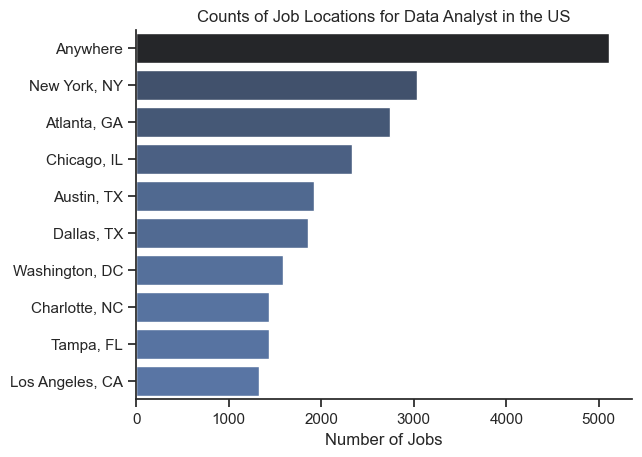

In [4]:
sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x="count", y=df_plot.index, hue="count", palette="dark:b_r", legend=False)
sns.despine()
plt.title("Counts of Job Locations for Data Analyst in the US")
plt.xlabel("Number of Jobs")
plt.ylabel("")
plt.show()

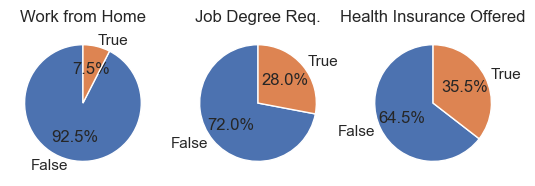

In [5]:
dict_column = {
    "job_work_from_home": "Work from Home",
    "job_no_degree_mention": "Job Degree Req.",
    "job_health_insurance": "Health Insurance Offered"
}

fig, ax= plt.subplots(1, 3)
fig.set_size=((12, 5))

for i, (column, title) in enumerate(dict_column.items()): 
    ax[i].pie(df_DA_US[column].value_counts(), startangle=90, autopct="%1.1f%%", labels=["False", "True"])
    ax[i].set_title(title)
    
plt.show()

## Count of Companies posting Data Analyst Jobs in the US

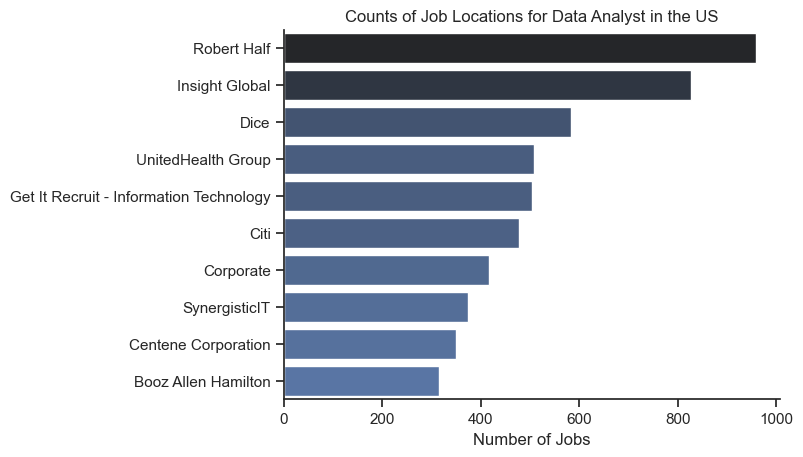

In [ ]:
df_plot = df_DA_US["company_name"].value_counts().head(10).to_frame() # wird zu DF umgewandelt

sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x="count", y=df_plot.index, hue="count", palette="dark:b_r", legend=False)
sns.despine()
plt.title("Counts of Comapnies for Data Analyst in the US")
plt.xlabel("Number of Jobs")
plt.ylabel("")
plt.show()

## Top 10 Websites Data Analyst Jobs are Posted in the US

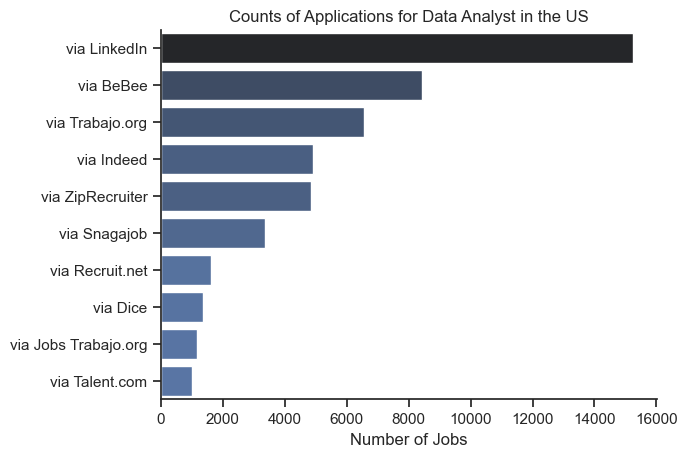

In [7]:
df_plot = df_DA_US["job_via"].value_counts().head(10).to_frame() # wird zu DF umgewandelt

sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x="count", y=df_plot.index, hue="count", palette="dark:b_r", legend=False)
sns.despine()
plt.title("Counts of Applications for Data Analyst in the US")
plt.xlabel("Number of Jobs")
plt.ylabel("")
plt.show()